1. Data Cleaning
2. EDA
3. Text Preprocessing
4. Model Building
5. Evaluation
6. Improvement
7. Website
8. Deployment

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

In [2]:
data = pd.read_csv(r"C:\Python\SMS Spam\Data\SMS_spam.csv", encoding="latin-1")
data.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [3]:
data.shape

(5572, 5)

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


In [5]:
df = data.copy()

In [6]:
## drop last 3 features
df.drop(columns=['Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], axis=1, inplace=True)
df.shape

(5572, 2)

In [7]:
df.head(2)

,v1,v2
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...


In [8]:
df.rename(columns={'v1':'target', 'v2':'text_data'}, inplace=True)
df.head()

,target,text_data
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [9]:
df['target'].value_counts()

target
ham     4825
spam     747
Name: count, dtype: int64

In [10]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()
df['target'] = encoder.fit_transform(df['target'])

In [11]:
df['target'].value_counts()

target
0    4825
1     747
Name: count, dtype: int64

In [12]:
df.isnull().sum()

target       0
text_data    0
dtype: int64

In [13]:
df.duplicated().sum()

403

In [14]:
## Remove duplicates
df.drop_duplicates(keep='first', inplace=True)

In [15]:
df.shape

(5169, 2)

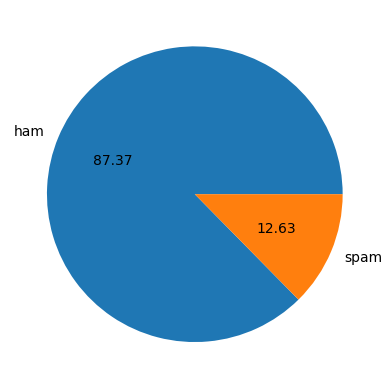

In [16]:
plt.pie(df['target'].value_counts(), labels=['ham', 'spam'], autopct="%0.2f")
plt.show()

In [17]:
import nltk
nltk.data.path.insert(0, r"C:\nltk_data")

In [18]:
df['num_characters'] = df['text_data'].apply(len)
df.head(3)

,target,text_data,num_characters
0,0,"Go until jurong point, crazy.. Available only ...",111
1,0,Ok lar... Joking wif u oni...,29
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155


In [19]:
from nltk.tokenize import word_tokenize
df['num_words'] = df['text_data'].apply(lambda x:len(nltk.word_tokenize(x)))
df.head(2)

,target,text_data,num_characters,num_words
0,0,"Go until jurong point, crazy.. Available only ...",111,24
1,0,Ok lar... Joking wif u oni...,29,8


In [20]:
df['num_sentences'] = df['text_data'].apply(lambda x:len(nltk.sent_tokenize(x)))  

In [21]:
df.head(2)

,target,text_data,num_characters,num_words,num_sentences
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2
1,0,Ok lar... Joking wif u oni...,29,8,2


In [22]:
df[['num_characters', 'num_words', 'num_sentences']].describe()

,num_characters,num_words,num_sentences
count,5169.000000,5169.000000,5169.000000
mean,78.977945,18.455794,1.965564
std,58.236293,13.324758,1.448541
min,2.000000,1.000000,1.000000
25%,36.000000,9.000000,1.000000
50%,60.000000,15.000000,1.000000
75%,117.000000,26.000000,2.000000
max,910.000000,220.000000,38.000000


In [23]:
## for ham messages
df[df['target'] == 0][['num_characters', 'num_words', 'num_sentences']].describe()

,num_characters,num_words,num_sentences
count,4516.000000,4516.000000,4516.000000
mean,70.459256,17.123782,1.820195
std,56.358207,13.493970,1.383657
min,2.000000,1.000000,1.000000
25%,34.000000,8.000000,1.000000
50%,52.000000,13.000000,1.000000
75%,90.000000,22.000000,2.000000
max,910.000000,220.000000,38.000000


In [24]:
## for spam messages
df[df['target'] == 1][['num_characters', 'num_words', 'num_sentences']].describe()

,num_characters,num_words,num_sentences
count,653.000000,653.000000,653.000000
mean,137.891271,27.667688,2.970904
std,30.137753,7.008418,1.488425
min,13.000000,2.000000,1.000000
25%,132.000000,25.000000,2.000000
50%,149.000000,29.000000,3.000000
75%,157.000000,32.000000,4.000000
max,224.000000,46.000000,9.000000


<Axes: xlabel='num_characters', ylabel='Count'>

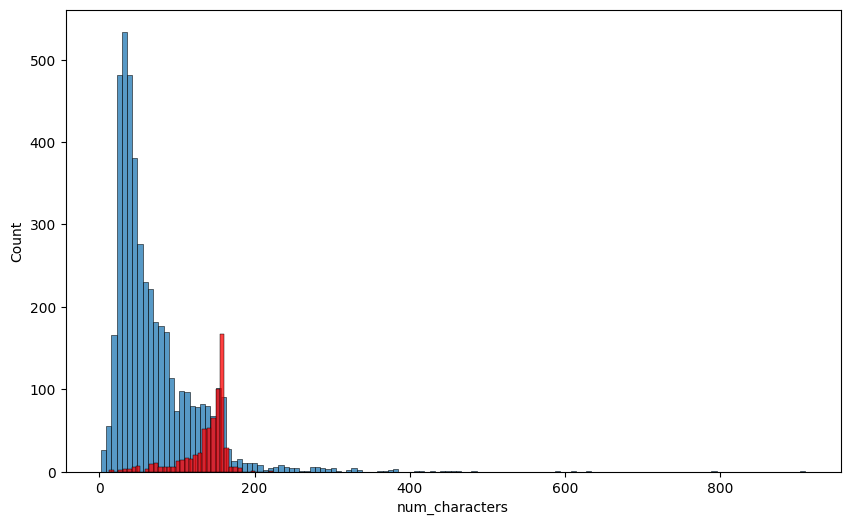

In [25]:
plt.figure(figsize=(10,6))
sns.histplot(df[df['target'] == 0]['num_characters'])
sns.histplot(df[df['target'] == 1]['num_characters'], color='red')

<Axes: xlabel='num_words', ylabel='Count'>

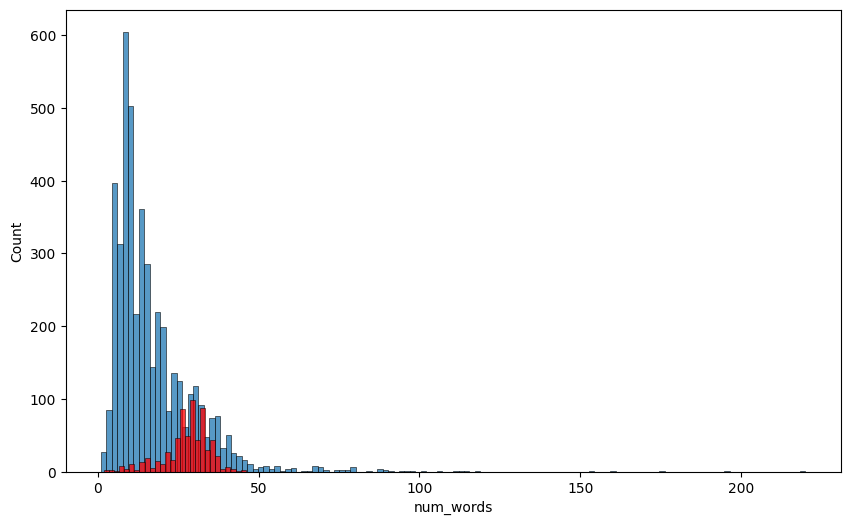

In [26]:
plt.figure(figsize=(10,6))
sns.histplot(df[df['target'] == 0]['num_words'])
sns.histplot(df[df['target'] == 1]['num_words'], color='red')

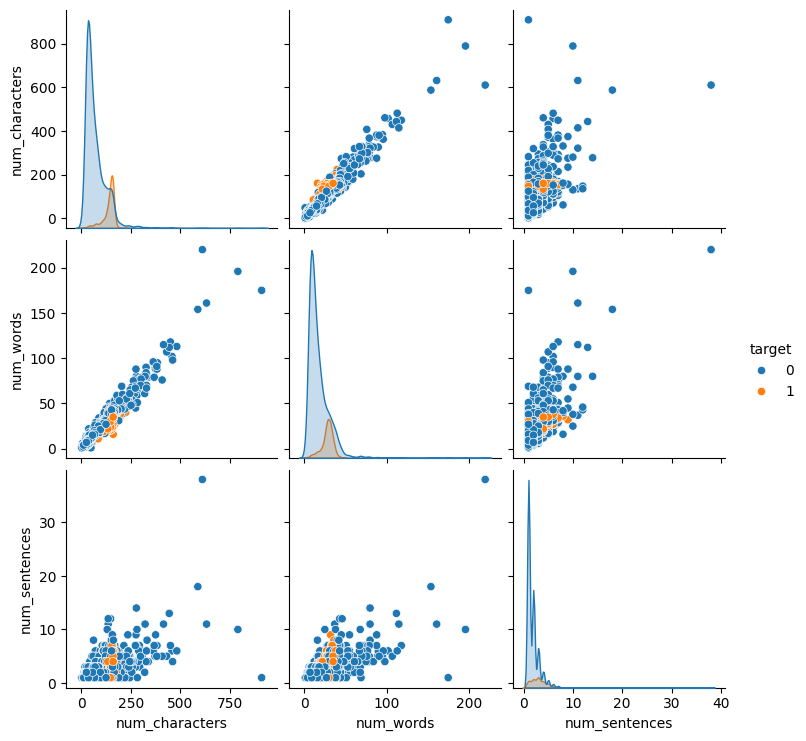

In [27]:
sns.pairplot(df, hue='target')

<Axes: >

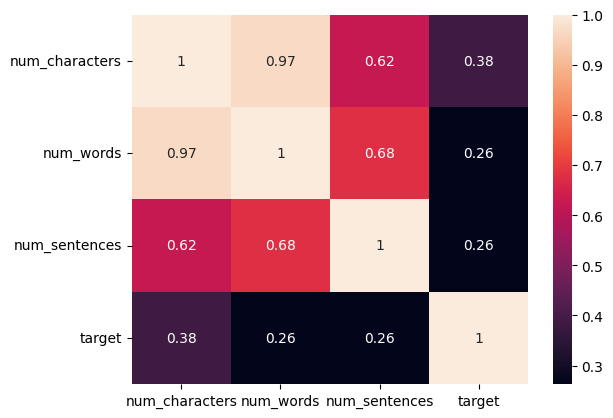

In [28]:
sns.heatmap(df[['num_characters', 'num_words', 'num_sentences','target']].corr(), annot=True)

#### Text Preprocessing
1. lower case
2. tokenization
3. removing special characters
4. removing stop words and punctuations
5. Stemming 

In [29]:
from nltk.corpus import stopwords
import string
string.punctuation

'!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~'

In [30]:
from nltk.stem.porter import PorterStemmer
ps = PorterStemmer()

In [31]:
def transform_text(text):
    text = text.lower()
    text = nltk.word_tokenize(text)

    y = []
    for i in text:
        if i.isalnum():
            y.append(i)

    text = y.copy()
    y.clear()

    for i in text:
        if i not in stopwords.words('english') and i not in string.punctuation:
            y.append(i)

    text = y.copy()
    y.clear()

    for i in text:
        y.append(ps.stem(i))

    return " ".join(y)

In [32]:
transform_text("I'm gonna be home soon and i don't want to talk about this stuff anymore tonight, k? I've cried enough today.")

'gon na home soon want talk stuff anymor tonight k cri enough today'

In [33]:
df['transformed_text'] = df['text_data'].apply(transform_text)

In [34]:
df.head(2)

,target,text_data,num_characters,num_words,num_sentences,transformed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni


In [35]:
a+b

NameError: name 'a' is not defined

In [ ]:
from wordcloud import WordCloud
wc = WordCloud(width=500, height=500, min_font_size=10, background_color='white')

In [ ]:
spam_wc = wc.generate(df[df['target'] == 1]['transformed_text'].str.cat(sep=" "))

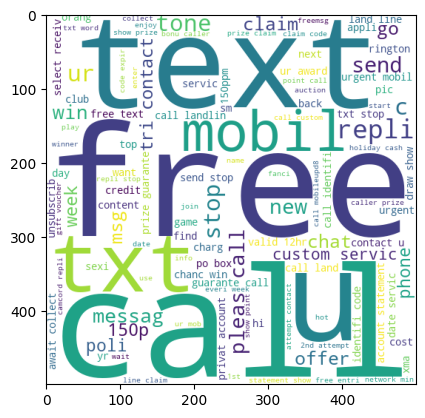

In [ ]:
plt.imshow(spam_wc)

In [ ]:
ham_wc =  wc.generate(df[df['target'] == 0]['transformed_text'].str.cat(sep=" "))

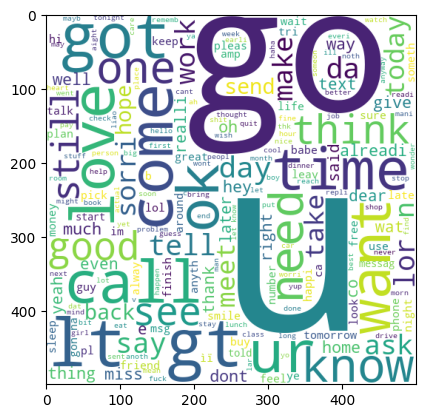

In [ ]:
plt.imshow(ham_wc)

In [ ]:
spam_corpus = []
for msg in df[df['target'] == 1]['transformed_text'].tolist():
    for word in msg.split():
        spam_corpus.append(word)

In [ ]:
len(spam_corpus)

9939

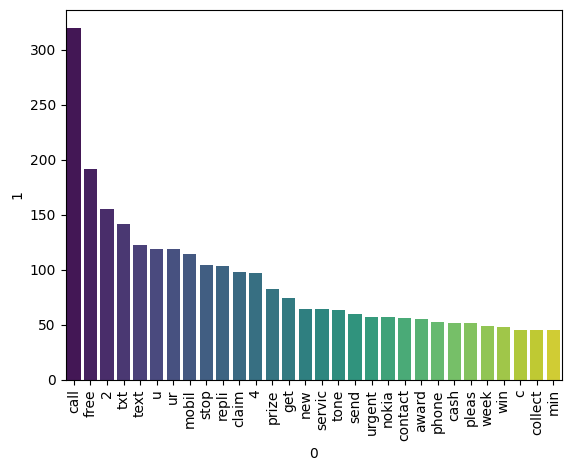

In [ ]:
from collections import Counter
sns.barplot(x=pd.DataFrame(Counter(spam_corpus).most_common(30))[0], y=pd.DataFrame(Counter(spam_corpus).most_common(30))[1], palette='viridis')
plt.xticks(rotation='vertical')
plt.show()

In [ ]:
ham_corpus = []
for msg in df[df['target'] == 0]['transformed_text'].tolist():
    for word in msg.split():
        ham_corpus.append(word)

In [ ]:
len(ham_corpus)

35404

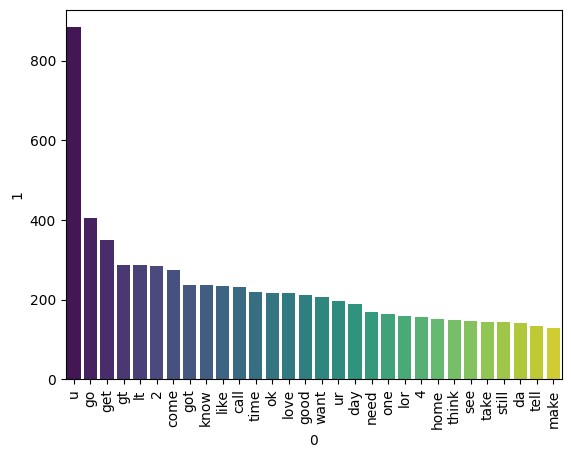

In [ ]:
sns.barplot(x=pd.DataFrame(Counter(ham_corpus).most_common(30))[0], y=pd.DataFrame(Counter(ham_corpus).most_common(30))[1], palette='viridis')
plt.xticks(rotation='vertical')
plt.show()

### Model Building

In [36]:
from sklearn.feature_extraction.text import CountVectorizer
cv = CountVectorizer()

In [37]:
X = cv.fit_transform(df['transformed_text']).toarray()
X.shape

(5169, 6708)

In [38]:
y = df['target'].values

In [39]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [40]:
from sklearn.naive_bayes import GaussianNB,MultinomialNB,BernoulliNB
from sklearn.metrics import accuracy_score,recall_score,confusion_matrix,precision_score

In [ ]:
gnb = GaussianNB()
mnb = MultinomialNB()
bnb = BernoulliNB()

In [ ]:
gnb.fit(X_train, y_train)
y_pred1 = gnb.predict(X_test)
print("Accuracy Score:{:.4f}".format(accuracy_score(y_test, y_pred1)))
print("Precision Score:{:.4f}".format(precision_score(y_test, y_pred1)))
print(confusion_matrix(y_test, y_pred1))

Accuracy Score:0.8685
Precision Score:0.5185
[[772 117]
 [ 19 126]]


In [ ]:
mnb.fit(X_train, y_train)
y_pred2 = mnb.predict(X_test)
print("Accuracy Score:{:.4f}".format(accuracy_score(y_test, y_pred2)))
print("Precision Score:{:.4f}".format(precision_score(y_test, y_pred2)))
print(confusion_matrix(y_test, y_pred2))

Accuracy Score:0.9739
Precision Score:0.8882
[[872  17]
 [ 10 135]]


In [ ]:
bnb.fit(X_train, y_train)
y_pred3 = bnb.predict(X_test)
print("Accuracy Score:{:.4f}".format(accuracy_score(y_test, y_pred3)))
print("Precision Score:{:.4f}".format(precision_score(y_test, y_pred3)))
print(confusion_matrix(y_test, y_pred3))

Accuracy Score:0.9662
Precision Score:0.9661
[[885   4]
 [ 31 114]]


In [41]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf = TfidfVectorizer()

In [ ]:
X = tfidf.fit_transform(df['transformed_text']).toarray()
y = df['target'].values
X_train,X_test,y_train,y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
gnb.fit(X_train, y_train)
y_pred1 = gnb.predict(X_test)
print('GaussianNB: ')
print("Accuracy Score:{:.4f}".format(accuracy_score(y_test, y_pred1)))
print("Precision Score:{:.4f}".format(precision_score(y_test, y_pred1)))
print(confusion_matrix(y_test, y_pred1))
print()

mnb.fit(X_train, y_train)
y_pred2 = mnb.predict(X_test)
print("MultinomialNB: ")
print("Accuracy Score:{:.4f}".format(accuracy_score(y_test, y_pred2)))
print("Precision Score:{:.4f}".format(precision_score(y_test, y_pred2)))
print(confusion_matrix(y_test, y_pred2))
print()

bnb.fit(X_train, y_train)
y_pred3 = bnb.predict(X_test)
print("BianryNB: ")
print("Accuracy Score:{:.4f}".format(accuracy_score(y_test, y_pred3)))
print("Precision Score:{:.4f}".format(precision_score(y_test, y_pred3)))
print(confusion_matrix(y_test, y_pred3))

GaussianNB: 
Accuracy Score:0.8636
Precision Score:0.5084
[[772 117]
 [ 24 121]]

MultinomialNB: 
Accuracy Score:0.9613
Precision Score:0.9907
[[888   1]
 [ 39 106]]

BianryNB: 
Accuracy Score:0.9662
Precision Score:0.9661
[[885   4]
 [ 31 114]]


In [42]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier, BaggingClassifier, ExtraTreesClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

In [43]:
models = {
    'LogisticRegression': LogisticRegression(),
    'RandomForest' : RandomForestClassifier(),
    'GradientBoost': GradientBoostingClassifier(),
    'AdaBoost': AdaBoostClassifier(),
    'DecisionTree': DecisionTreeClassifier(),
    'KNN': KNeighborsClassifier(),
    'SVM': SVC(),
    'XGBoost': XGBClassifier(),
    'Bagging': BaggingClassifier(),
    'ExtraTrees': ExtraTreesClassifier()
}

In [44]:
from sklearn.metrics import f1_score,recall_score,precision_score,accuracy_score

In [45]:
def evaluate_model(true, pred):
    accuracy = accuracy_score(true, pred)
    precision = precision_score(true, pred, average='binary')
    recall = recall_score(true, pred, average='binary')
    f1 = f1_score(true, pred, average='binary')

    return accuracy, precision, recall, f1

In [46]:
def train_classifier(model, X_train, y_train, X_test, y_test):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    return accuracy, precision

In [ ]:
accuracy_scores = []
precision_scores = []

for name,model in models.items():
    current_accuracy, current_precision = train_classifier(model, X_train, y_train, X_test, y_test)
    accuracy_scores.append(current_accuracy)
    precision_scores.append(current_precision)



KeyboardInterrupt: 

In [ ]:
performance_df1 = pd.DataFrame({'Algorithm': models.keys(), 'Accuracy': accuracy_scores, 'Precision': precision_scores})

In [ ]:
performance_df1.sort_values(by='Precision', ascending=False)

,Algorithm,Accuracy,Precision
5,KNN,0.896518,1.000000
1,RandomForest,0.968085,0.991228
6,SVM,0.968085,0.991228
9,ExtraTrees,0.973888,0.968254
2,GradientBoost,0.964217,0.965517
7,XGBoost,0.973888,0.953846
0,LogisticRegression,0.948743,0.942308
8,Bagging,0.959381,0.875912
3,AdaBoost,0.947776,0.842105
4,DecisionTree,0.946809,0.812500


### Model Improvement

In [47]:
tfidf = TfidfVectorizer(max_features=3000)

In [48]:
X = tfidf.fit_transform(df['transformed_text']).toarray()
y = df['target'].values
X_train,X_test,y_train,y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
accuracy_scores = []
precision_scores = []

for name,model in models.items():
    current_accuracy, current_precision = train_classifier(model, X_train, y_train, X_test, y_test)
    accuracy_scores.append(current_accuracy)
    precision_scores.append(current_precision)

In [ ]:
performance_df2 = pd.DataFrame({'Algorithm': models.keys(), 'Accuracy': accuracy_scores, 'Precision': precision_scores})

In [ ]:
mnb = MultinomialNB()
mnb.fit(X_train, y_train)
y_pred = mnb.predict(X_test)
performance_df2.loc[len(performance_df2)] = {
    'Algorithm': 'MultinomialNB',
    'Accuracy': accuracy_score(y_pred, y_test),
    'Precision': precision_score(y_pred, y_test)
}

In [ ]:
performance_df2.sort_values(by='Precision', ascending=False)

,Algorithm,Accuracy,Precision
5,KNN,0.907157,1.000000
6,SVM,0.974855,0.991736
1,RandomForest,0.972921,0.991597
2,GradientBoost,0.959381,0.963964
9,ExtraTrees,0.974855,0.961240
0,LogisticRegression,0.958414,0.947368
7,XGBoost,0.969052,0.931298
8,Bagging,0.962282,0.884058
3,AdaBoost,0.950677,0.867188
4,DecisionTree,0.948743,0.823944


In [ ]:
performance_df1.merge(performance_df2, on='Algorithm')

,Algorithm,Accuracy_x,Precision_x,Accuracy_y,Precision_y
0,LogisticRegression,0.948743,0.942308,0.958414,0.947368
1,RandomForest,0.968085,0.991228,0.972921,0.991597
2,GradientBoost,0.964217,0.965517,0.959381,0.963964
3,AdaBoost,0.947776,0.842105,0.950677,0.867188
4,DecisionTree,0.946809,0.812500,0.948743,0.823944
5,KNN,0.896518,1.000000,0.907157,1.000000
6,SVM,0.968085,0.991228,0.974855,0.991736
7,XGBoost,0.973888,0.953846,0.969052,0.931298
8,Bagging,0.959381,0.875912,0.962282,0.884058
9,ExtraTrees,0.973888,0.968254,0.974855,0.961240


In [55]:
model = SVC()
model.fit(X_train, y_train)

SVC()

In [ ]:
import pickle
pickle.dump(tfidf, open("vectorizer.pkl", "wb"))

In [53]:
pickle.dump(model, open("model.pkl", "wb"))